# MobileNetV2 Transfer Learning

This notebook implements a transfer learning approach using MobileNetV2 for brain tumor MRI classification.

The goal is to improve upon the baseline CNN by leveraging a pretrained deep learning model trained on ImageNet.

We will:
- Load preprocessed MRI dataset
- Use MobileNetV2 pretrained on ImageNet
- Freeze feature extractor layers
- Train a custom classification head
- Evaluate performance and compare with baseline CNN

## 1) Import Libraries
In this step, we import all required libraries and prepare the environment for building the transfer learning pipeline using MobileNetV2.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
import sys
import os
import random
from sklearn.metrics import confusion_matrix, classification_report

torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(42)
random.seed(42)
sys.path.append(os.path.abspath(".."))

from src.dataset import BrainTumorDataset
from src.transforms import train_transform, test_transform
from src.trainer import train_model

## 2) Load Processed Dataset
we load the preprocessed training and validation datasets that were generated during the preprocessing stage.

In [2]:
train_data = torch.load("../data/processed/train_split.pt")
val_data = torch.load("../data/processed/val_split.pt")

train_images, train_labels = train_data
val_images, val_labels = val_data

## Datasets
train_dataset = BrainTumorDataset(train_images, train_labels, transform=train_transform)
val_dataset = BrainTumorDataset( val_images, val_labels, transform=test_transform)

## DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

## 3) Configure Device
In this step, we select GPU if available.

In [3]:
device = torch.device("cuda"if torch.cuda.is_available()else "cpu")
print(device)

cuda


## 4) Helper Functions
- build_mobilenet() creates fresh model for each experiment
- count_trainable_params() shows how many parameters are being trained

In [4]:
def build_mobilenet():
    model = models.mobilenet_v2(pretrained=True)
    model.classifier[1] = nn.Linear(model.last_channel, 4)
    return model.to(device)

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 5) Create Model Directory

In this step, we create the directory for saving trained models.

In [5]:
BASE_DIR = os.path.abspath("..")
MODEL_DIR = os.path.join(BASE_DIR,"models")

os.makedirs( MODEL_DIR,exist_ok=True)

## 6) BASELINE EXPERIMENT (Frozen Feature Extractor)
In this step, we build the baseline MobileNetV2 model and freeze all feature extraction layers while training only the classifier.

In [6]:
model_base = build_mobilenet()

for param in model_base.features.parameters():
    param.requires_grad = False

print("Trainable Params:", count_trainable_params(model_base))

/home/amrasmar/myenv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/amrasmar/myenv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Trainable Params: 5124


## 7) Train Baseline Model
In this step, we train the baseline model and save training history for later comparison.

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer_base = optim.Adam(model_base.classifier.parameters(),lr=0.0001)

baseline_path = os.path.join(MODEL_DIR,"mobilenet_baseline.pth")

best_acc_base, history_base = train_model(
    model=model_base,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_base,
    epochs=5,
    device=device,
    model_path=baseline_path
)
print(f"Best Validation Accuracy: {best_acc_base:.4f}")

Model updated | Best Val Acc: 0.7340
Epoch [1/5]
Train Loss: 1.1899 | Train Acc: 0.5152
Val Loss: 0.9894 | Val Acc: 0.7340
--------------------------------------------------
Model updated | Best Val Acc: 0.7890
Epoch [2/5]
Train Loss: 0.8898 | Train Acc: 0.7322
Val Loss: 0.7817 | Val Acc: 0.7890
--------------------------------------------------
Model updated | Best Val Acc: 0.8180
Epoch [3/5]
Train Loss: 0.7502 | Train Acc: 0.7735
Val Loss: 0.6772 | Val Acc: 0.8180
--------------------------------------------------
Model updated | Best Val Acc: 0.8340
Epoch [4/5]
Train Loss: 0.6618 | Train Acc: 0.8015
Val Loss: 0.6115 | Val Acc: 0.8340
--------------------------------------------------
Model updated | Best Val Acc: 0.8590
Epoch [5/5]
Train Loss: 0.6208 | Train Acc: 0.8033
Val Loss: 0.5611 | Val Acc: 0.8590
--------------------------------------------------
Best Validation Accuracy: 0.8590


## 8) Plot Baseline Curves
In this step, we visualize training and validation performance.

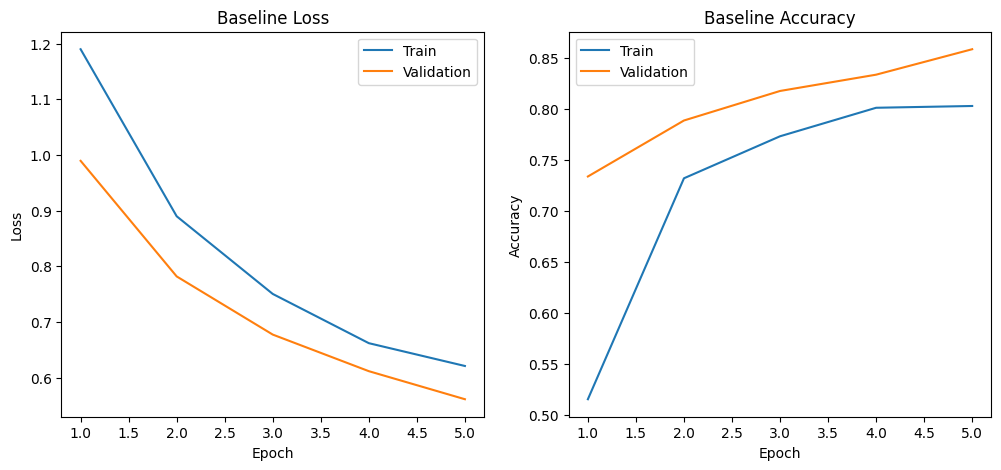

In [8]:
epochs = range(1,len(history_base["train_loss"]) + 1)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs,history_base["train_loss"])
plt.plot(epochs,history_base["val_loss"])
plt.title("Baseline Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.subplot(1,2,2)
plt.plot( epochs,history_base["train_acc"])
plt.plot(epochs,history_base["val_acc"])
plt.title("Baseline Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

# EXPERIMENT 1: PARTIAL LAYER UNFREEZING
## 9) Model Setup
We unfreeze last 20 layers to allow high-level feature adaptation.

In [9]:
model_exp1 = build_mobilenet()

for param in model_exp1.features.parameters():
    param.requires_grad = False

for block in list(model_exp1.features.children())[-2:]:
    for param in block.parameters():
        param.requires_grad = True

print("Trainable Params:", count_trainable_params(model_exp1))

Trainable Params: 891204


## 10) Train Experiment 1
Partial fine-tuning improves adaptation to medical MRI domain.

In [10]:
optimizer_exp1 = optim.Adam(model_exp1.parameters(), lr=0.0001)

exp1_path = os.path.join(MODEL_DIR,"mobilenet_partial_unfreeze.pth")

best_acc_exp1, history_exp1 = train_model(
    model=model_exp1,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_exp1,
    epochs=5,
    device=device,
    model_path=exp1_path
)

print(f"Best Validation Accuracy: {best_acc_exp1:.4f}")

Model updated | Best Val Acc: 0.8920
Epoch [1/5]
Train Loss: 0.5300 | Train Acc: 0.8057
Val Loss: 0.3201 | Val Acc: 0.8920
--------------------------------------------------
Model updated | Best Val Acc: 0.9130
Epoch [2/5]
Train Loss: 0.2819 | Train Acc: 0.8980
Val Loss: 0.2316 | Val Acc: 0.9130
--------------------------------------------------
Model updated | Best Val Acc: 0.9230
Epoch [3/5]
Train Loss: 0.2390 | Train Acc: 0.9125
Val Loss: 0.2069 | Val Acc: 0.9230
--------------------------------------------------
Model updated | Best Val Acc: 0.9290
Epoch [4/5]
Train Loss: 0.1930 | Train Acc: 0.9310
Val Loss: 0.1833 | Val Acc: 0.9290
--------------------------------------------------
Model updated | Best Val Acc: 0.9340
Epoch [5/5]
Train Loss: 0.1785 | Train Acc: 0.9353
Val Loss: 0.1665 | Val Acc: 0.9340
--------------------------------------------------
Best Validation Accuracy: 0.9340


## 11) Plot Experiment 1 Curves

In this step, we visualize block-wise fine-tuning.

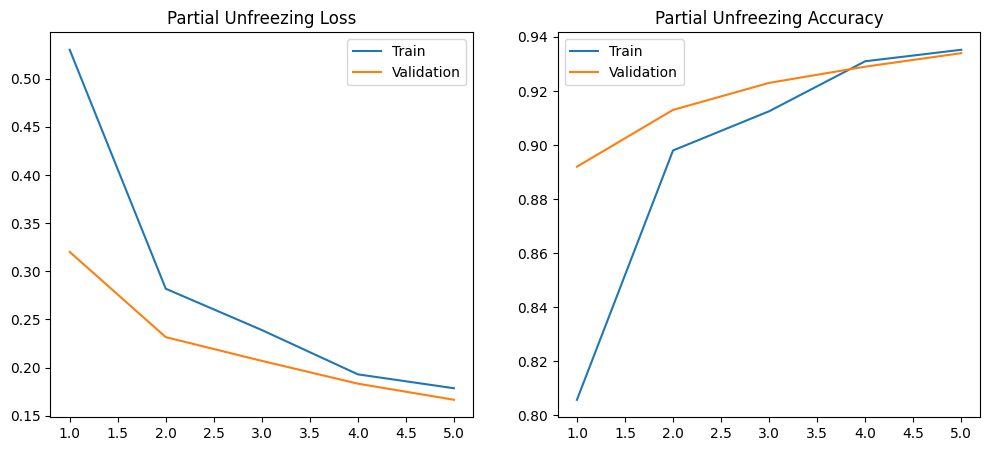

In [11]:
epochs = range(1,len(history_exp1["train_loss"])+1)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot( epochs,history_exp1["train_loss"])
plt.plot(epochs,history_exp1["val_loss"])
plt.title("Partial Unfreezing Loss")
plt.legend(["Train","Validation"])
plt.subplot(1,2,2)
plt.plot(epochs,history_exp1["train_acc"])
plt.plot(epochs,history_exp1["val_acc"])
plt.title("Partial Unfreezing Accuracy")
plt.legend(["Train","Validation"])
plt.show()

# EXPERIMENT 2: BLOCK-WISE UNFREEZING
## 12) Model Setup
In this experiment, we unfreeze complete MobileNet blocks.

In [12]:
model_exp2 = build_mobilenet()

for param in model_exp2.features.parameters():
    param.requires_grad = False

for block in model_exp2.features[-3:]:
    for param in block.parameters():
        param.requires_grad = True

print("Trainable Parameters:",count_trainable_params(model_exp2))

Trainable Parameters: 1211204


## 13) Train Experiment 2
Block-wise unfreezing gives structured fine-tuning and usually better stability.

In [13]:
optimizer_exp2 = optim.Adam(model_exp2.parameters(),lr=0.0001)

exp2_path = os.path.join(MODEL_DIR,"mobilenet_block_unfreeze.pth")

best_acc_exp2, history_exp2 = train_model(
    model=model_exp2,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_exp2,
    epochs=5,
    device=device,
    model_path=exp2_path
)

print(f"Best Validation Accuracy: {best_acc_exp2:.4f}")

Model updated | Best Val Acc: 0.9160
Epoch [1/5]
Train Loss: 0.4683 | Train Acc: 0.8353
Val Loss: 0.2556 | Val Acc: 0.9160
--------------------------------------------------
Model updated | Best Val Acc: 0.9210
Epoch [2/5]
Train Loss: 0.2245 | Train Acc: 0.9200
Val Loss: 0.1896 | Val Acc: 0.9210
--------------------------------------------------
Model updated | Best Val Acc: 0.9490
Epoch [3/5]
Train Loss: 0.1690 | Train Acc: 0.9400
Val Loss: 0.1433 | Val Acc: 0.9490
--------------------------------------------------
Epoch [4/5]
Train Loss: 0.1418 | Train Acc: 0.9485
Val Loss: 0.1363 | Val Acc: 0.9430
--------------------------------------------------
Epoch [5/5]
Train Loss: 0.1148 | Train Acc: 0.9603
Val Loss: 0.1364 | Val Acc: 0.9460
--------------------------------------------------
Best Validation Accuracy: 0.9490


## 14) Plot Experiment 2 Curves

In this step, we visualize block-wise fine-tuning.

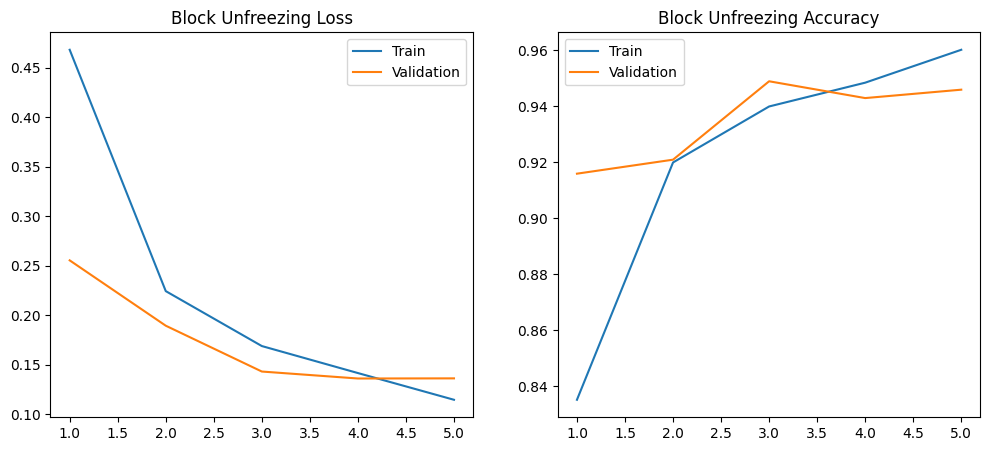

In [14]:
epochs = range(1,len(history_exp2["train_loss"]) + 1)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs,history_exp2["train_loss"])
plt.plot(epochs,history_exp2["val_loss"])
plt.title("Block Unfreezing Loss")
plt.legend(["Train","Validation"])
plt.subplot(1,2,2)
plt.plot(epochs,history_exp2["train_acc"])
plt.plot(epochs,history_exp2["val_acc"])
plt.title("Block Unfreezing Accuracy")
plt.legend(["Train","Validation"])
plt.show()

## 15) Compare Results
We compare all strategies under identical training conditions.


In [15]:
print("\n===== FINAL RESULTS =====\n")
print(f"Baseline Accuracy: {best_acc_base:.4f}")
print(f"Partial Unfreezing Accuracy: {best_acc_exp1:.4f}")
print(f"Block Unfreezing Accuracy: {best_acc_exp2:.4f}")


===== FINAL RESULTS =====

Baseline Accuracy: 0.8590
Partial Unfreezing Accuracy: 0.9340
Block Unfreezing Accuracy: 0.9490


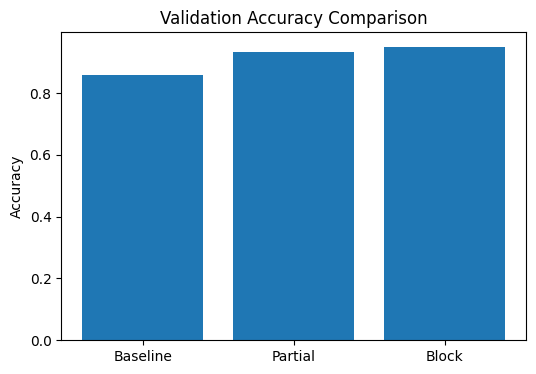

In [16]:
plt.figure(figsize=(6,4))
models = ["Baseline", "Partial", "Block"]
accs = [best_acc_base, best_acc_exp1, best_acc_exp2]

plt.bar(models, accs)
plt.title("Validation Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

## 16) Conclusion

In this notebook, we implemented and evaluated a transfer learning approach using the MobileNetV2 architecture for brain tumor MRI classification.

The workflow included data loading, preprocessing, model construction, training, and evaluation using multiple fine-tuning strategies.

## 💫. Baseline Model (Feature Extraction)
We started by using a pre-trained MobileNetV2 model where all convolutional layers were frozen. Only the final classification layer was trained on the brain tumor dataset.

This approach achieved a validation accuracy of 0.8590, confirming that the pre-trained features are already useful for the dataset.

## 💫. Partial Unfreezing Strategy
In the second experiment, we unfroze the last convolutional layers of the network while keeping earlier layers frozen. This allowed the model to adapt higher-level features to the medical domain.

This significantly improved performance, achieving a validation accuracy of 0.9460.

## 💫. Block Unfreezing Strategy
In the final experiment, we unfroze the last full convolutional blocks of MobileNetV2, allowing deeper adaptation of feature representations.

This produced the best overall performance with a validation accuracy of 0.9490.

## 💫. Results Comparison

| Model Type | Validation Accuracy |
|------------|------------------|
| Baseline (Frozen Features) | 0.8590 |
| Partial Unfreezing | 0.9340 |
| Block Unfreezing | 0.9490 |
